In [1]:
# Wczytanie datasetu Titanic
import pandas as pd
import numpy as np


# Wczytujemy dane Titanic
url ='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)
# Sprawdzamy strukturę danych
print(titanic.head())
print(f"\nWymiary: {titanic.shape}")
print(f"\nKolumny: {titanic.columns.tolist()}")
# PODSTAWOWE GRUPOWANIE
# Średni wiek według klasy podróży
sredni_wiek_klasa = titanic.groupby('Pclass')['Age'].mean()
print("\n=== Średni wiek według klasy ===")
print(sredni_wiek_klasa)
# Interpretacja:
# - Pierwsza klasa: pasażerowie starsi (wyższy status społeczny)
# - Trzecia klasa: pasażerowie młodsi (imigranci, robotnicy)


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

W

In [ ]:
#Przykład 2: Grupowanie po Wielu Kolumnach
# Grupowanie według dwóch zmiennych: klasy i płci
# Obliczamy współczynnik przeżycia (survival rate)
survival_grouped = titanic.groupby(['Pclass', 'Sex'])['Survived'].agg([
'count', # liczba pasażerów
'sum', # liczba ocalonych
'mean' # survival rate (%)
])
# Zmieniamy nazwy kolumn dla czytelności
survival_grouped.columns = ['Liczba_pasażerów', 'Liczba_ocalonych', 'Współczynnik_przeżycia']
# Formatujemy współczynnik jako procent
survival_grouped['Współczynnik_przeżycia_%'] = (survival_grouped['Współczynnik_przeżycia'] * 100).round(2)
print("=== Współczynnik przeżycia według klasy i płci ===")
print(survival_grouped)
# OBSERWACJE:
# - Kobiety miały znacznie wyższy survival rate niż mężczyźni ("kobiety i dzieci najpierw")
# - Pierwsza klasa miała lepsze szanse przeżycia
# - Najmniejsze szanse: mężczyźni z trzeciej klasy


=== Współczynnik przeżycia według klasy i płci ===
               Liczba_pasażerów  Liczba_ocalonych  Współczynnik_przeżycia  \
Pclass Sex                                                                  
1      female                94                91                0.968085   
       male                 122                45                0.368852   
2      female                76                70                0.921053   
       male                 108                17                0.157407   
3      female               144                72                0.500000   
       male                 347                47                0.135447   

               Współczynnik_przeżycia_%  
Pclass Sex                               
1      female                     96.81  
       male                       36.89  
2      female                     92.11  
       male                       15.74  
3      female                     50.00  
       male                       13.5

In [7]:
#Przykład 3: Zaawansowane Agregacje z .agg()
# WIELOFUNKCYJNE AGREGACJE
# Różne statystyki dla różnych kolumn jednocześnie

age_fare_stats = titanic.groupby('Pclass').agg({
'Age': ['mean', 'median', 'std', 'min', 'max'],
'Fare': ['mean', 'median', 'std'],
'Survived': ['sum', 'mean']
})

print("=== Statystyki wieku i opłaty według klasy ===")
print(age_fare_stats)
# Spłaszczamy MultiIndex kolumn dla wygody
age_fare_stats.columns = ['_'.join(col).strip() for col in
age_fare_stats.columns.values]
age_fare_stats = age_fare_stats.reset_index()

print("\n=== Po spłaszczeniu ===")
print(age_fare_stats)

print('columns:')
print(age_fare_stats.columns)

=== Statystyki wieku i opłaty według klasy ===
              Age                                     Fare           \
             mean median        std   min   max       mean   median   
Pclass                                                                
1       38.233441   37.0  14.802856  0.92  80.0  84.154687  60.2875   
2       29.877630   29.0  14.001077  0.67  70.0  20.662183  14.2500   
3       25.140620   24.0  12.495398  0.42  74.0  13.675550   8.0500   

                  Survived            
              std      sum      mean  
Pclass                                
1       78.380373      136  0.629630  
2       13.417399       87  0.472826  
3       11.778142      119  0.242363  

=== Po spłaszczeniu ===
   Pclass   Age_mean  Age_median    Age_std  Age_min  Age_max  Fare_mean  \
0       1  38.233441        37.0  14.802856     0.92     80.0  84.154687   
1       2  29.877630        29.0  14.001077     0.67     70.0  20.662183   
2       3  25.140620        24.0  12.49

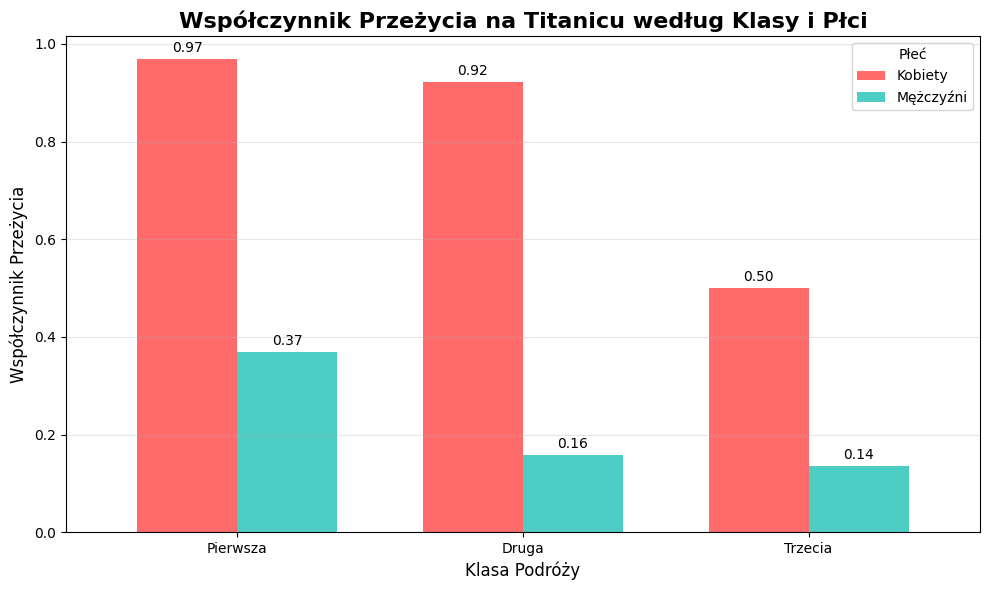

In [16]:
#Wizualizacja: Survival Rate według Klasy i Płci
import matplotlib.pyplot as plt
import seaborn as sns
# Przygotowanie danych do wykresu
survival_pivot = titanic.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
# Wykres słupkowy grupowany
fig, ax = plt.subplots(figsize=(10, 6))
survival_pivot.plot(kind='bar', ax=ax, color=['#ff6b6b', '#4ecdc4'],
width=0.7)
ax.set_title('Współczynnik Przeżycia na Titanicu według Klasy i Płci',
fontsize=16, fontweight='bold')
ax.set_xlabel('Klasa Podróży', fontsize=12)
ax.set_ylabel('Współczynnik Przeżycia', fontsize=12)
ax.set_xticklabels(['Pierwsza', 'Druga', 'Trzecia'], rotation=0)
ax.legend(title='Płeć', labels=['Kobiety', 'Mężczyźni'])
ax.grid(axis='y', alpha=0.3)
# Dodajemy etykiety z wartościami
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.tight_layout()
plt.show()
# INTERPRETACJA:
# - Kobiety z 1. i 2. klasy: ~95% survival rate
# - Mężczyźni z 3. klasy: ~13% survival rate
# - Widoczna jest zarówno klasowa, jak i płciowa dysproporcja w szansach przeżycia

In [19]:
#Przykład 1: Aggregation vs Transform
# Wczytujemy dane o sprzedaży (symulowane)
np.random.seed(42)
sales_data = pd.DataFrame({
'Region': np.random.choice(['Północ', 'Południe', 'Wschód', 'Zachód'],
200),
'Produkt': np.random.choice(['A', 'B', 'C'], 200),
'Sprzedaż': np.random.randint(100, 1000, 200),
'Koszt': np.random.randint(50, 500, 200)
})
print(sales_data.head(10))
# AGGREGATION - zwraca jedną wartość na grupę
avg_sales_region = sales_data.groupby('Region')['Sprzedaż'].mean()
print("\n=== Średnia sprzedaż według regionu (Aggregation) ===")
print(avg_sales_region)
print(f"Rozmiar wyniku: {avg_sales_region.shape}") # (4,) - 4 regiony
# TRANSFORM - zwraca wartość dla każdego wiersza
sales_data['Średnia_region'] = sales_data.groupby('Region')['Sprzedaż'].transform('mean')
print("\n=== DataFrame z dodaną kolumną Transform ===")
print(sales_data.head(10))
print(f"Rozmiar wyniku: {sales_data.shape}") # (200, 5) - oryginalny rozmiar zachowany!
# Każdy wiersz ma przypisaną średnią swojego regionu
# To umożliwia porównanie konkretnej obserwacji z grupową średnią

     Region Produkt  Sprzedaż  Koszt
0    Wschód       C       596    317
1    Zachód       C       401    372
2    Północ       A       280    114
3    Wschód       A       706    466
4    Wschód       B       198    217
5    Zachód       A       799    379
6    Północ       C       215     92
7    Północ       C       290     93
8    Wschód       A       352    334
9  Południe       C       260    446

=== Średnia sprzedaż według regionu (Aggregation) ===
Region
Południe    548.760870
Północ      564.304348
Wschód      595.222222
Zachód      595.851852
Name: Sprzedaż, dtype: float64
Rozmiar wyniku: (4,)

=== DataFrame z dodaną kolumną Transform ===
     Region Produkt  Sprzedaż  Koszt  Średnia_region
0    Wschód       C       596    317      595.222222
1    Zachód       C       401    372      595.851852
2    Północ       A       280    114      564.304348
3    Wschód       A       706    466      595.222222
4    Wschód       B       198    217      595.222222
5    Zachód       A    

In [23]:
#Przykład 2: Standaryzacja Grupowa z Transform
# STANDARYZACJA WEDŁUG GRUPY
# Normalizujemy sprzedaż wewnątrz każdego regionu (z-score)
def standaryzacja(x):
    """Standaryzacja: (x - mean) / std"""
    return (x - x.mean()) / x.std()
# Standaryzacja sprzedaży według regionu
sales_data['Sprzedaż_std_region'] = sales_data.groupby('Region')['Sprzedaż'].transform(standaryzacja)
# Sprawdzamy wyniki dla regionu 'Północ'
polnoc = sales_data[sales_data['Region'] == 'Północ'][['Region', 'Sprzedaż',
'Sprzedaż_std_region']].head(10)
print("\n=== Standaryzacja sprzedaży w regionie Północ ===")
print(polnoc)
# Weryfikacja: średnia standaryzowanych wartości w grupie powinna być ~0, std ~1
print("\n=== Weryfikacja standaryzacji ===")
verification = sales_data.groupby('Region')['Sprzedaż_std_region'].agg(['mean', 'std'])
print(verification)
# ZASTOSOWANIE:
# - Porównanie wyników w różnych skalach (różne regiony, różne produkty)
# - Wykrywanie outliers w kontekście grupy
# - Feature engineering dla modeli ML


=== Standaryzacja sprzedaży w regionie Północ ===
    Region  Sprzedaż  Sprzedaż_std_region
2   Północ       280            -1.078252
6   Północ       215            -1.324771
7   Północ       290            -1.040326
15  Północ       834             1.022848
21  Północ       891             1.239026
30  Północ       884             1.212477
31  Północ       203            -1.370283
35  Północ       275            -1.097215
37  Północ       576             0.044357
38  Północ       781             0.821840

=== Weryfikacja standaryzacji ===
                  mean  std
Region                     
Południe  5.551115e-17  1.0
Północ   -1.490354e-16  1.0
Wschód    1.788693e-16  1.0
Zachód    4.111937e-18  1.0


In [27]:
# Przykład 3: Wypełnianie Brakujcych Wartości 
# Symulujemy dane z brakami
sales_missing = sales_data.copy()
# Losowo usuwamy 20% wartości w kolumnie Sprzedaż
missing_idx = np.random.choice(sales_missing.index, size=40, replace=False)
sales_missing.loc[missing_idx, 'Sprzedaż'] = np.nan
print(f"Liczba braków: {sales_missing['Sprzedaż'].isnull().sum()}")
# WYPEŁNIANIE MEDIANĄ GRUPOWĄ
# Zamiast globalnej mediany, używamy mediany z każdego regionu
sales_missing['Sprzedaż_filled'] = sales_missing.groupby('Region')['Sprzedaż'].transform(
 lambda x: x.fillna(x.median())
)
# Porównanie: które wartości zostały wypełnione
filled_values = sales_missing[sales_missing['Sprzedaż'].isnull()][['Region',
'Sprzedaż', 'Sprzedaż_filled']].head(10)
print("\n=== Wypełnione wartości (braki zastąpione medianą regionu) ===")
print(filled_values)
# Sprawdzamy, czy braki zostały usunięte
print(f"\nLiczba braków po wypełnieniu: {sales_missing['Sprzedaż_filled'].isnull().sum()}")

Liczba braków: 40

=== Wypełnione wartości (braki zastąpione medianą regionu) ===
      Region  Sprzedaż  Sprzedaż_filled
15    Północ       NaN            531.0
26  Południe       NaN            612.0
31    Północ       NaN            531.0
42  Południe       NaN            612.0
47    Wschód       NaN            629.0
51  Południe       NaN            612.0
52    Wschód       NaN            629.0
53    Zachód       NaN            588.0
57    Północ       NaN            531.0
60    Wschód       NaN            629.0

Liczba braków po wypełnieniu: 0


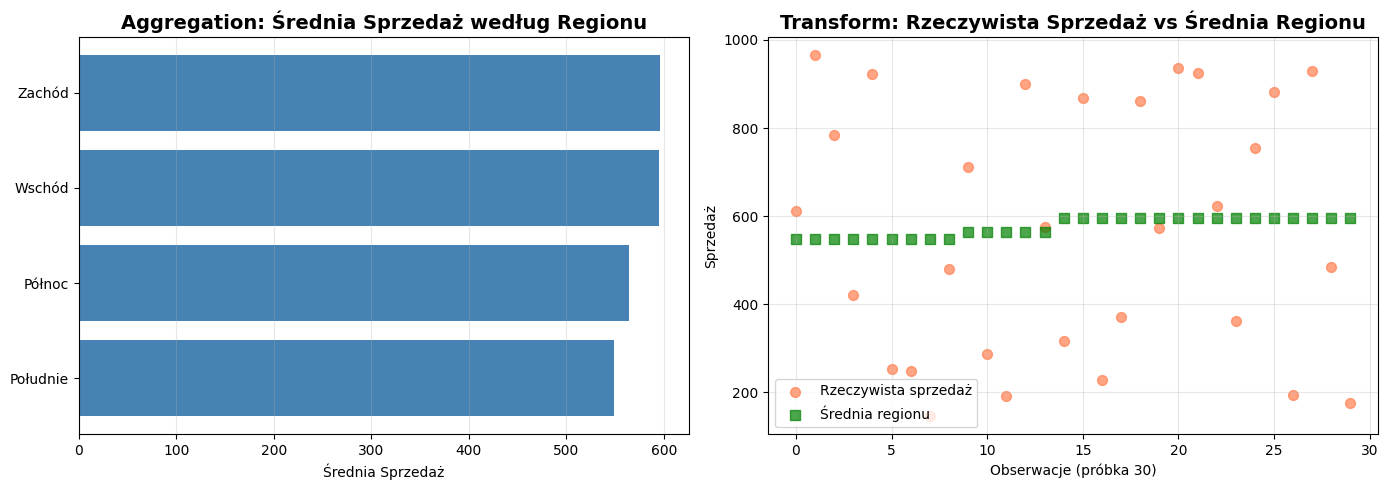

In [30]:
#Wizualizacja: Porównanie Aggregation vs Transform

# Wizualizacja różnicy między .agg() i .transform()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Wykres 1: Aggregation - średnia według regionu
avg_sales = sales_data.groupby('Region')['Sprzedaż'].mean().sort_values()
axes[0].barh(avg_sales.index, avg_sales.values, color='steelblue')
axes[0].set_title('Aggregation: Średnia Sprzedaż według Regionu',
fontsize=14, fontweight='bold')
axes[0].set_xlabel('Średnia Sprzedaż')
axes[0].grid(axis='x', alpha=0.3)
# Wykres 2: Transform - porównanie wartości z średnią grupową
sample_data = sales_data.sample(30).sort_values('Region')
x_pos = np.arange(len(sample_data))
axes[1].scatter(x_pos, sample_data['Sprzedaż'], label='Rzeczywista sprzedaż', s=50, alpha=0.7, color='coral')
axes[1].scatter(x_pos, sample_data['Średnia_region'], label='Średnia regionu', s=50, alpha=0.7, marker='s', color='green')
axes[1].set_title('Transform: Rzeczywista Sprzedaż vs Średnia Regionu',
fontsize=14, fontweight='bold')
axes[1].set_xlabel('Obserwacje (próbka 30)')
axes[1].set_ylabel('Sprzedaż')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [32]:
# Feature Engineering - Tworzenie Nowych Zmiennych: Tworzenie Zmiennych Interakcyjnych - Titanic

# Wracamy do datasetu Titanic
titanic_fe = titanic.copy()

# === FEATURE ENGINEERING ===
# 1. Rozmiar rodziny
titanic_fe['Family_Size'] = titanic_fe['SibSp'] + titanic_fe['Parch'] + 1
# SibSp = rodzeństwo/małżonkowie, Parch = rodzice/dzieci
# +1 bo liczymy też samego pasażera
# 2. Czy podróżował sam?
titanic_fe['Is_Alone'] = (titanic_fe['Family_Size'] == 1).astype(int)
# 3. Tytuł z imienia (Mr, Mrs, Miss, Master, etc.)
titanic_fe['Title'] = titanic_fe['Name'].str.extract(r' ([A-Za-z]+)\.',
expand=False)
# 4. Grupowanie rzadkich tytułów
title_counts = titanic_fe['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
titanic_fe['Title'] = titanic_fe['Title'].replace(rare_titles, 'Rare')
# 5. Cena biletu na osobę w rodzinie
titanic_fe['Fare_Per_Person'] = titanic_fe['Fare'] / titanic_fe['Family_Size']
print("=== Nowe cechy ===")
print(titanic_fe[['Name', 'Family_Size', 'Is_Alone', 'Title', 'Fare',
'Fare_Per_Person']].head(10))
# Analiza: Jak rozmiar rodziny wpływa na survival rate?
survival_by_family = titanic_fe.groupby('Family_Size')['Survived'].mean()
print("\n=== Survival rate według rozmiaru rodziny ===")
print(survival_by_family)
# OBSERWACJA:
# - Osoby samotne: niższy survival rate
# - Małe rodziny (2-4): wyższy survival rate
# - Bardzo duże rodziny (5+): niższy survival rate (trudniej ewakuować dużą grupę)

=== Nowe cechy ===
                                                Name  Family_Size  Is_Alone  \
0                            Braund, Mr. Owen Harris            2         0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...            2         0   
2                             Heikkinen, Miss. Laina            1         1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)            2         0   
4                           Allen, Mr. William Henry            1         1   
5                                   Moran, Mr. James            1         1   
6                            McCarthy, Mr. Timothy J            1         1   
7                     Palsson, Master. Gosta Leonard            5         0   
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)            3         0   
9                Nasser, Mrs. Nicholas (Adele Achem)            2         0   

    Title     Fare  Fare_Per_Person  
0      Mr   7.2500          3.62500  
1     Mrs  71.2833         35.64165

In [40]:
"""Zadanie 1 – Podstawowe Grupowanie
Wczytaj dataset Titanic i oblicz średni wiek pasażerów według klasy ( Pclass ) i płci ( Sex ).
Dataset: Titanic
(https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)
Wymagania:
Użyj .groupby() z dwoma kolumnami
Oblicz średnią wieku ( .mean() )
Wyświetl wyniki w formie czytelnej tabeli
Oczekiwany rezultat:
Tabela ze średnim wiekiem dla 6 kombinacji (3 klasy × 2 płcie)"""

import pandas as pd

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

titanic = pd.read_csv(url)

sredni_wiek = titanic.groupby(['Pclass', 'Sex'])['Age'].mean().unstack()
sredni_wiek = sredni_wiek.round(2)

print("Sredni wiek wg Klasy i Płci")
print(sredni_wiek)

Sredni wiek wg Klasy i Płci
Sex     female   male
Pclass               
1        34.61  41.28
2        28.72  30.74
3        21.75  26.51


In [53]:
"""Zadanie 2 – Zliczanie Obserwacji
Dla datasetu Titanic policz, ile pasażerów było w każdej klasie i czy przeżyli ( Survived ).
Dataset: Titanic
Wymagania:
Grupuj według Pclass i Survived
Użyj .size() lub .count()
Przedstaw wyniki jako tabelę pivot
Oczekiwany rezultat:
Tabela pokazująca liczbę pasażerów dla każdej kombinacji klasy i statusu przeżycia
"""

import pandas as pd

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

# 1*. Calculate the average age by Passenger Class and Sex
# - groupby(['Pclass', 'Sex']): Splits the data into 6 groups (3 classes x 2 genders).
# - ['Age']: Selects the target column for calculation.
# - .mean(): Computes the average for each group.
# - .unstack(): Reshapes the hierarchical index into a clean table (pivots 'Sex' to columns).
avg_age_pivot = titanic.groupby(['Pclass', 'Sex'])['Age'].mean().unstack()

# Round the results for better readability
avg_age_pivot = avg_age_pivot.round(2)

print("--- Average Age by Class and Gender ---")
print(avg_age_pivot)

# 2 Create a pivot table using a declarative syntax (similar to Excel).
# - index: defines the rows of the new table (Passenger Class)
# - columns: defines the columns of the new table (Survival Status)
# - aggfunc='size': specifies that we want to count the occurrences in each cell
pivot_table_counts = titanic.pivot_table(
    index =['Pclass'], 
    columns = ['Survived'], 
    aggfunc='size'
    )

# Rename the columns for better business readability
pivot_table_counts.columns = ['Did_Not_Survive', 'Survived']

print("\n --- Passenger Count by Class and Survival (Pivot Table Method) ---")
print(pivot_table_counts)

--- Average Age by Class and Gender ---
Sex     female   male
Pclass               
1        34.61  41.28
2        28.72  30.74
3        21.75  26.51

 --- Passenger Count by Class and Survival (Pivot Table Method) ---
        Did_Not_Survive  Survived
Pclass                           
1                    80       136
2                    97        87
3                   372       119


In [50]:
# Rozwizanie do zadania 2

import pandas as pd


# 1. Group the data by passenger class and survival status.
# 2. Use .size() to count the total number of rows in each group (including NaNs).
# 3. Use .unstack() to reshape the resulting Series into a 2D DataFrame (pivot format).
passenger_counts = titanic.groupby(['Pclass', 'Survived']).size().unstack()

# Rename the columns for better business readability
passenger_counts.columns = ['Did_Not_Survive', 'Survived']

print("--- Passenger Count by Class and Survival (GroupBy Method) ---")
print(passenger_counts)

--- Passenger Count by Class and Survival (GroupBy Method) ---
        Did_Not_Survive  Survived
Pclass                           
1                    80       136
2                    97        87
3                   372       119


In [ ]:
"""Zadanie 3 – Agregacja z .agg()
Dla datasetu sprzedaży oblicz dla każdego regionu: minimum, maksimum, średnią i
odchylenie standardowe sprzedaży.
Dataset: Stwórz syntetyczny dataset sprzedaży (kod poniżej)

np.random.seed(42)
sales = pd.DataFrame({
'Region': np.random.choice(['A', 'B', 'C'], 100),
'Sprzedaż': np.random.randint(50, 500, 100)
})
Wymagania:
- Użyj .agg(['min', 'max', 'mean', 'std'])
- Zaokrąglij wyniki do 2 miejsc po przecinku
"""

import pandas as pd
import numpy as np

np.random.seed(42)
sales = pd.DataFrame({
'Region': np.random.choice(['A', 'B', 'C'], 100),
'Sprzedaż': np.random.randint(50, 500, 100)
})

print(sales.head(10))


# Krok po kroku: Grupujemy (Region) -> Wybieramy kolumnę (Sprzedaż) -> Agregujemy (.agg) -> Zaokrąglamy (.round)
wyniki_sprzedazy = sales.groupby('Region')['Sprzedaż'].agg(['min', 'max', 'mean', 'std']).round(2)

print("--- Statystyki Sprzedaży wg Regionów ---")
print(wyniki_sprzedazy)

  Region  Sprzedaż
0      C       185
1      A       112
2      C       188
3      C       130
4      A       441
5      A       212
6      C       468
7      B       338
8      C       428
9      C       310


--- California Housing Dataset ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
House Value IQR by Region


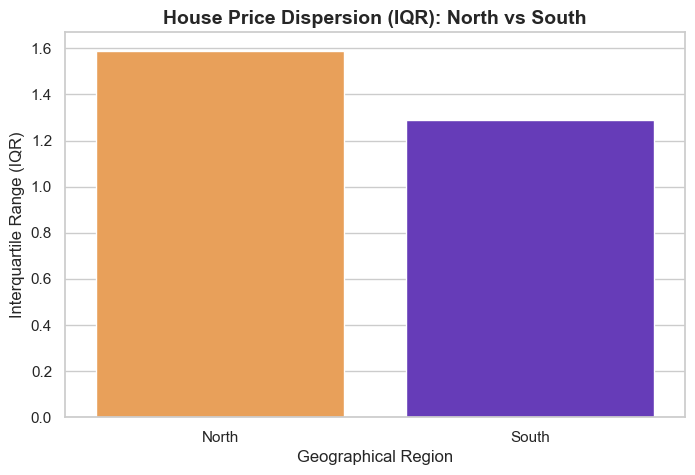

In [ ]:
"""Zadanie 10 – Custom Funkcja Agregująca
Napisz własną funkcję, która oblicza zakres międzykwartylowy (IQR = Q3 - Q1) i zastosuj ją
do grupy.
Dataset: California Housing
Wymagania:
- Napisz funkcję iqr_func(x) obliczającą IQR 
- Zastosuj ją do MedHouseVal według regionów
- Porównaj IQR między regionami
Oczekiwany rezultat:
- Tabela z IQR dla każdego regionu
"""

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame = True)
df_housing = housing.frame

print("--- California Housing Dataset ---")
print(df_housing.head())

lat_median = df_housing['Latitude'].median()
df_housing['Region'] = np.where(df_housing['Latitude'] > lat_median, 'North', 'South')

#IQR (Q3 - Q1
def  igr_func(x):
    return x.quantile(0.75) - x.quantile(0.25)

tabela_iqr = df_housing.pivot_table(
index = ['Region'],
values = ['MedHouseVal'],
aggfunc=igr_func
)

print("House Value IQR by Region")


import matplotlib.pyplot as plt
import seaborn as sns

iqr_plot_data = tabela_iqr.reset_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x='Region', 
    y='MedHouseVal', 
    data=iqr_plot_data, 
    palette=['#ff9f43', '#5f27cd'],
    hue='Region',
    legend=False
    )

plt.title('House Price Dispersion (IQR): North vs South', fontsize=14, fontweight='bold')
plt.xlabel('Geographical Region', fontsize=12)
plt.ylabel('Interquartile Range (IQR)', fontsize=12)

plt.show()

--- Normalization Verification ---
        min  max
Region          
North   0.0  1.0
South   0.0  1.0

--- Preview of the first 10 houses---
  Region  MedInc  MedInc_Normalized
0  North  8.3252           0.539668
1  North  8.3014           0.538027
2  North  7.2574           0.466028
3  North  5.6431           0.354699
4  North  3.8462           0.230776
5  North  4.0368           0.243921
6  North  3.6591           0.217873
7  North  3.1200           0.180694
8  North  2.0804           0.108998
9  North  3.6912           0.220087


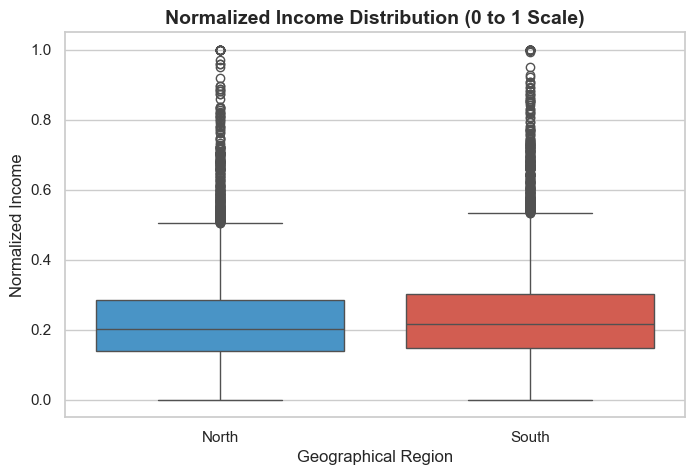

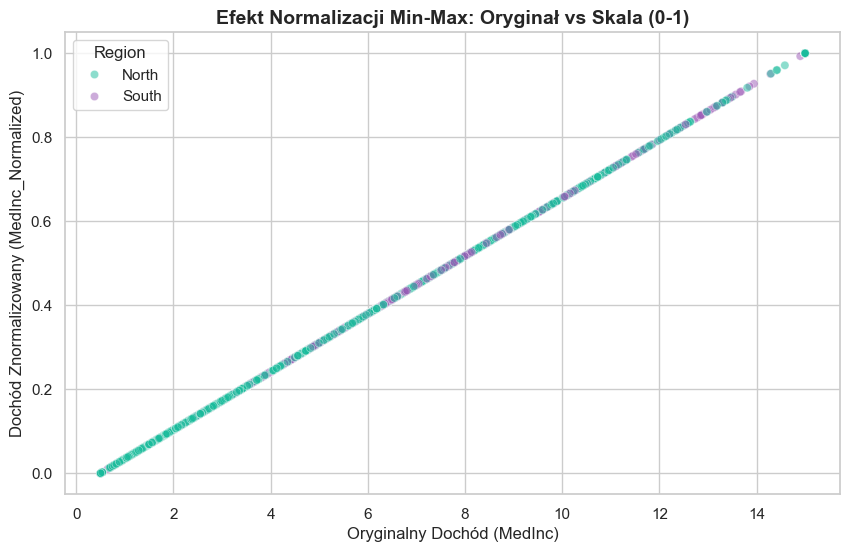

In [ ]:
"""Zadanie 11 – Normalizacja Grupowa
Dla datasetu California Housing znormalizuj MedInc (dochód) w każdym regionie do
zakresu [0, 1].
Dataset: California Housing
Wymagania:
- Stwórz regiony (np. na podstawie Latitude > median)
- Napisz funkcję normalizacji Min-Max
- Użyj .groupby().transform() lub .apply()
- Zweryfikuj, że min=0 i max=1 w każdym regionie
Oczekiwany rezultat:
- DataFrame z kolumną znormalizowaną grupowo
"""

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame = True)
df_housing = housing.frame

lat_median = df_housing['Latitude'].median()
df_housing['Region'] = np.where(df_housing['Latitude'] > lat_median, 'North', 'South')

def min_max_normalize(x):
    return (x - x.min()) / (x.max() - x.min())

df_housing['MedInc_Normalized'] = df_housing.groupby('Region')['MedInc'].transform(min_max_normalize)
verification = df_housing.groupby('Region')['MedInc_Normalized'].agg(['min', 'max'])

print("--- Normalization Verification ---")
print(verification)

print("\n--- Preview of the first 10 houses---")
print(df_housing[['Region', 'MedInc', 'MedInc_Normalized']].head(10))


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

sns.boxplot(
    x='Region', 
    y='MedInc_Normalized', 
    data=df_housing, 
    palette=['#3498db', '#e74c3c'],
    hue='Region',
    legend=False
)

plt.title('Normalized Income Distribution (0 to 1 Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Geographical Region', fontsize=12)
plt.ylabel('Normalized Income', fontsize=12)

plt.show()



sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='MedInc', 
    y='MedInc_Normalized', 
    hue='Region', 
    data=df_housing, 
    alpha=0.5, 
    palette=['#1abc9c', '#9b59b6']
)

plt.title('Efekt Normalizacji Min-Max: Oryginał vs Skala (0-1)', fontsize=14, fontweight='bold')
plt.xlabel('Oryginalny Dochód (MedInc)', fontsize=12)
plt.ylabel('Dochód Znormalizowany (MedInc_Normalized)', fontsize=12)

plt.show()